In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocess the data
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape the data to add a channel dimension
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Define the MML model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\nTest accuracy:', test_acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 29ms/step - accuracy: 0.8988 - loss: 0.3292 - val_accuracy: 0.9871 - val_loss: 0.0394
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9847 - loss: 0.0492 - val_accuracy: 0.9879 - val_loss: 0.0367
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9899 - loss: 0.0329 - val_accuracy: 0.9908 - val_loss: 0.0272
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9926 - loss: 0.0234 - val_accuracy: 0.9909 - val_loss: 0.0278
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 28ms/step - accuracy: 0.9940 - loss: 0.0176 - val_accuracy: 0.9895 - val_loss: 0.0334
313/313 - 2s - 8ms/step - accuracy: 0.9895 - loss: 0.0334

Test accuracy: 0.9894999861717224


In [ ]:
import matplotlib.pyplot as plt

def draw_mnist_image(image_array):
  """Draws a single MNIST image.

  Args:
    image_array: A numpy array representing the MNIST image (28x28x1).
  """
  plt.imshow(image_array.reshape(28, 28), cmap='gray')
  plt.axis('off')
  plt.show()

# Example usage (assuming x_test is available from the previous cell):
# draw_mnist_image(x_test[0])

In [ ]:
import numpy as np

def add_noise(image_array, noise_level=0.1):
  """Adds random noise to an image.

  Args:
    image_array: A numpy array representing the image.
    noise_level: The standard deviation of the random noise to add.

  Returns:
    A numpy array representing the image with added noise.
  """
  noise = np.random.normal(loc=0, scale=noise_level, size=image_array.shape)
  noisy_image = image_array + noise
  # Clip values to be within the valid range [0, 1]
  noisy_image = np.clip(noisy_image, 0, 1)
  return noisy_image

# Example usage (assuming x_test is available from the previous cell):
# noisy_image = add_noise(x_test[0], noise_level=0.2)
# draw_mnist_image(noisy_image) # You'll need the draw_mnist_image function from before

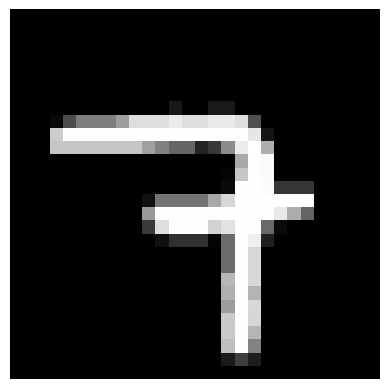

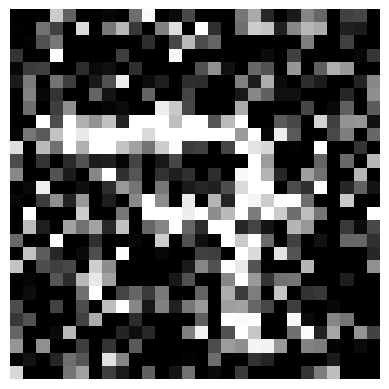

In [ ]:
 i = np.random.randint(len(x_test))
 noise_level = 0.45
 image = x_test[i]
 noise_image = add_noise(image, noise_level=noise_level)
 draw_mnist_image(image)
 draw_mnist_image(noise_image)

In [ ]:
# Assuming 'model' is your trained model and 'image' is the image you want to predict on

# The model expects a batch of images, so you need to add an extra dimension
image = np.expand_dims(image, axis=0)

# Make the prediction
predictions = model.predict(image)

# The predictions are probabilities for each class (digit).
# To get the predicted digit, find the index with the highest probability.
predicted_digit = np.argmax(predictions[0])

print(f'Predictions: {predictions}')
print(f'Predictions[{y_test[i]}]={predictions[0][y_test[i]]}')
print("Predicted digit:", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predictions: [[2.1239460e-10 9.0416069e-07 5.9329970e-05 5.0881703e-04 1.4274216e-05
  3.5091452e-07 2.1344714e-11 9.9931753e-01 9.6070363e-10 9.8791897e-05]]
Predictions[7]=0.9993175268173218
Predicted digit: 7


In [ ]:
# The model expects a batch of images, so you need to add an extra dimension
noise_image = np.expand_dims(noise_image, axis=0)

# Make the prediction
predictions = model.predict(noise_image)

# The predictions are probabilities for each class (digit).
# To get the predicted digit, find the index with the highest probability.
predicted_digit = np.argmax(predictions[0])

print(f'Predictions: {predictions}')
print(f'Predictions[{y_test[i]}]={predictions[0][y_test[i]]}')
print("Predicted digit:", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predictions: [[2.2785868e-04 4.2492966e-03 1.9214982e-02 2.1514872e-02 1.2861707e-02
  2.9245471e-03 1.9597579e-05 9.2696321e-01 1.4861461e-03 1.0537912e-02]]
Predictions[7]=0.926963210105896
Predicted digit: 7


Testing 10 images with noise (noise_level=0.45):

Image index: 3454
True label: 1
Original prediction: 1
Noisy prediction: 1
Original Image:


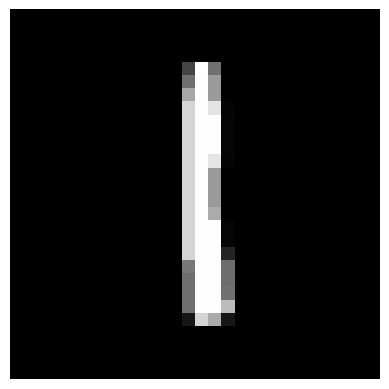

Noisy Image:


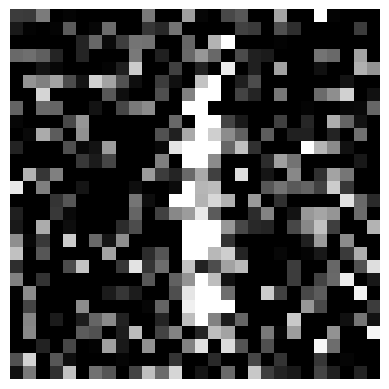

--------------------
Image index: 9554
True label: 9
Original prediction: 9
Noisy prediction: 9
Original Image:


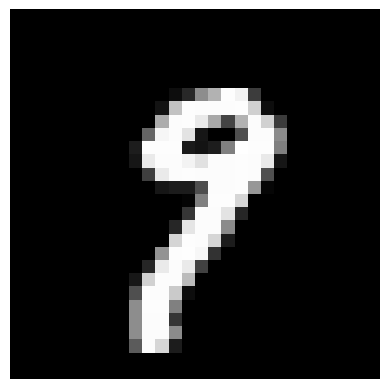

Noisy Image:


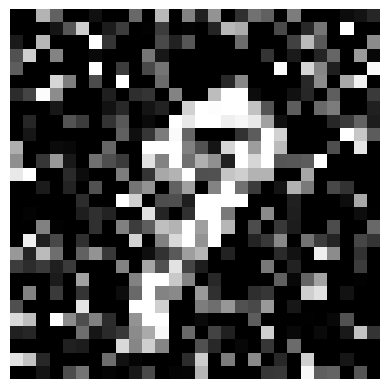

--------------------
Image index: 3485
True label: 9
Original prediction: 9
Noisy prediction: 9
Original Image:


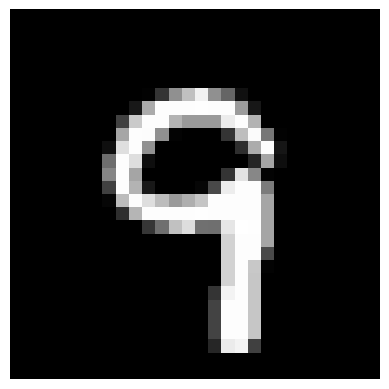

Noisy Image:


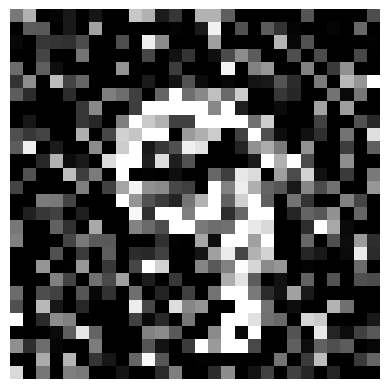

--------------------
Image index: 3359
True label: 0
Original prediction: 0
Noisy prediction: 0
Original Image:


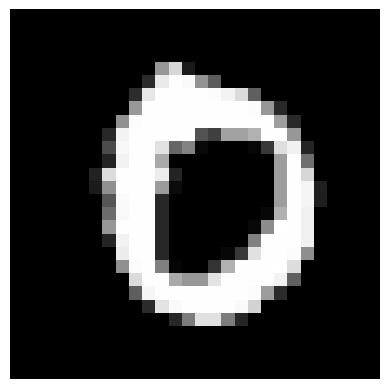

Noisy Image:


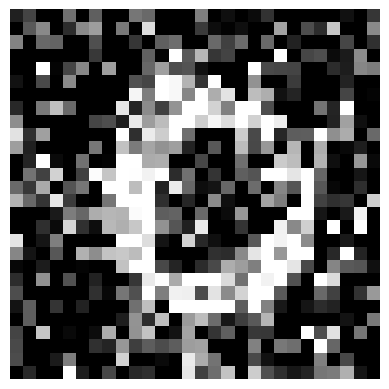

--------------------
Image index: 3256
True label: 2
Original prediction: 2
Noisy prediction: 2
Original Image:


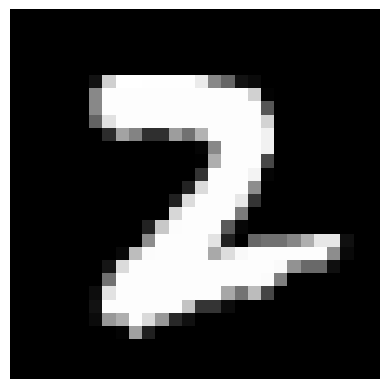

Noisy Image:


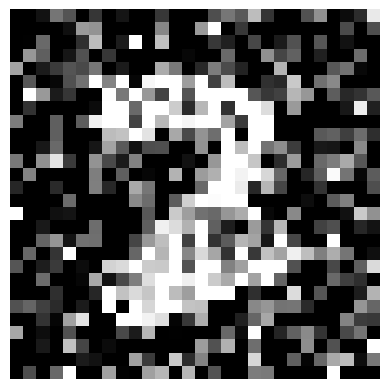

--------------------
Image index: 8389
True label: 0
Original prediction: 0
Noisy prediction: 0
Original Image:


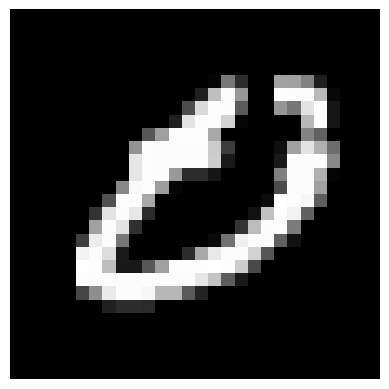

Noisy Image:


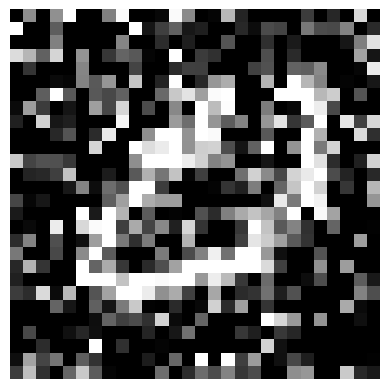

--------------------
Image index: 7763
True label: 3
Original prediction: 3
Noisy prediction: 3
Original Image:


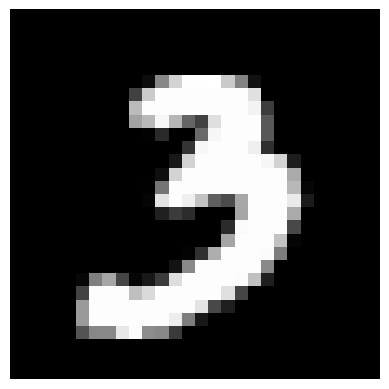

Noisy Image:


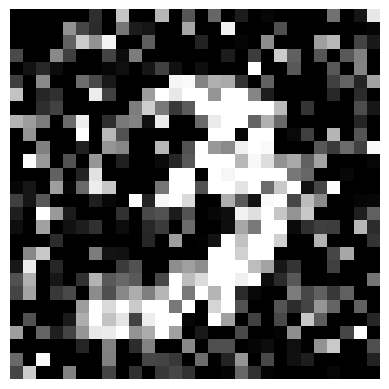

--------------------
Image index: 840
True label: 1
Original prediction: 1
Noisy prediction: 1
Original Image:


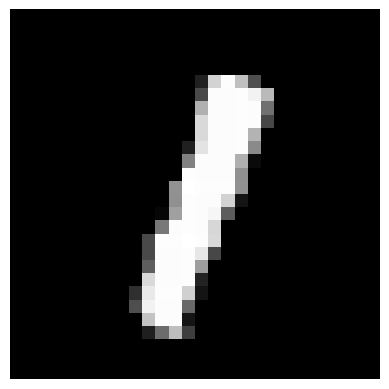

Noisy Image:


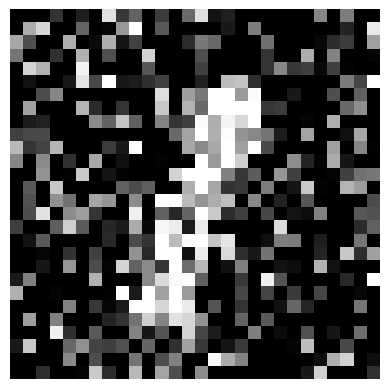

--------------------
Image index: 3079
True label: 7
Original prediction: 7
Noisy prediction: 7
Original Image:


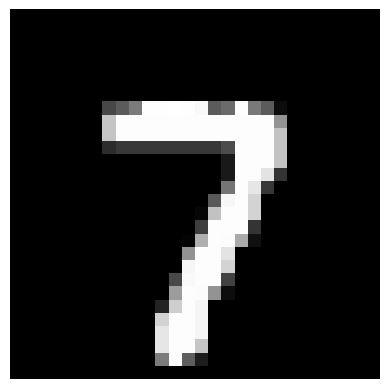

Noisy Image:


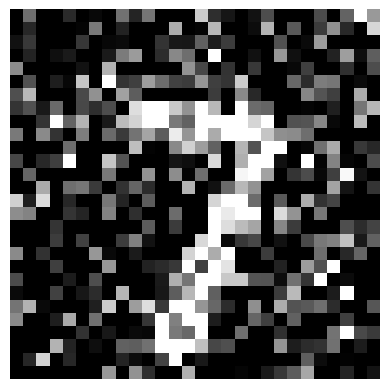

--------------------
Image index: 7216
True label: 0
Original prediction: 0
Noisy prediction: 5
Original Image:


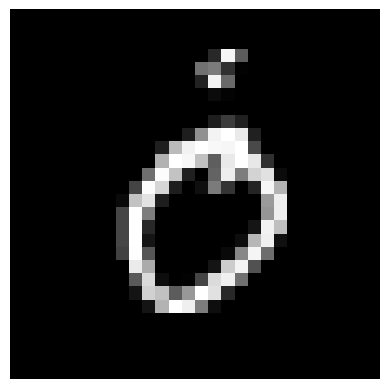

Noisy Image:


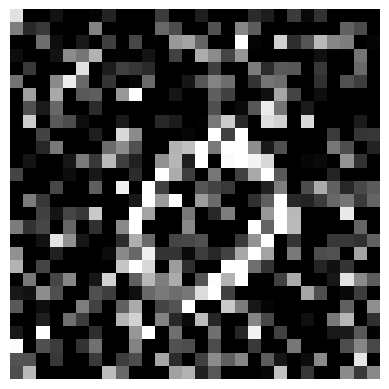

--------------------


In [ ]:
import numpy as np

# Select 10 random indices from the test set
num_images_to_test = 10
random_indices = np.random.choice(len(x_test), num_images_to_test, replace=False)

print(f"Testing {num_images_to_test} images with noise (noise_level=0.45):\n")

for i in random_indices:
  image = x_test[i]
  true_label = y_test[i]

  # Make prediction on original image
  original_image_for_prediction = np.expand_dims(image, axis=0)
  original_predictions = model.predict(original_image_for_prediction, verbose=0)
  original_predicted_digit = np.argmax(original_predictions[0])

  # Add noise and make prediction on noisy image
  noisy_image = add_noise(image, noise_level=0.45)
  noisy_image_for_prediction = np.expand_dims(noisy_image, axis=0)
  noisy_predictions = model.predict(noisy_image_for_prediction, verbose=0)
  noisy_predicted_digit = np.argmax(noisy_predictions[0])

  print(f"Image index: {i}")
  print(f"True label: {true_label}")
  print(f"Original prediction: {original_predicted_digit}")
  print(f"Noisy prediction: {noisy_predicted_digit}")

  # Draw original and noisy images
  print("Original Image:")
  draw_mnist_image(image)
  print("Noisy Image:")
  draw_mnist_image(noisy_image)

  print("-" * 20)

In [ ]:
import requests
import json

def send_to_online_mml(data, api_url, api_key):
  """Отправляет данные к онлайн-модели MML через API.

  Args:
    data: Данные для отправки модели (например, изображение в байтах или закодированном виде).
    api_url: URL эндпоинта API онлайн-модели.
    api_key: Ваш API-ключ для аутентификации.

  Returns:
    Ответ от API модели в формате JSON, или None в случае ошибки.
  """
  headers = {
      'Content-Type': 'application/json',
      'Authorization': f'Bearer {api_key}' # Формат заголовка может отличаться в зависимости от API
  }

  try:
    response = requests.post(api_url, headers=headers, data=json.dumps(data))
    response.raise_for_status() # Вызывает исключение для плохих ответов (4xx или 5xx)
    return response.json()
  except requests.exceptions.RequestException as e:
    print(f"Ошибка при отправке запроса: {e}")
    return None

# Пример использования (Вам нужно заменить значения на реальные):
# api_endpoint = 'YOUR_API_ENDPOINT_URL'
# your_api_key = 'YOUR_API_KEY'
# test_data = {"image_data": "...", "other_params": "..."} # Формат данных зависит от API DeepSeek

# result = send_to_online_mml(test_data, api_endpoint, your_api_key)

# if result:
#   print("Результат от модели:", result)

In [ ]:
!pip install requests